# **0. Load Preliminary Functions**

# a. Import Libraries and Functions

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
# device = torch.device('cpu')


cuda


# b. MNIST Data Loader

In [2]:
def binarize_image(tensor):
    return (tensor > 0.5).float()

tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(binarize_image)
])

batch_size = 128
train_dataset = datasets.MNIST(root = "./data",
									train = True,
									download = False,
									transform = tensor_transform)
test_dataset = datasets.MNIST(root = "./data",
									train = False,
									download = False,
									transform = tensor_transform)

train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
							   batch_size = batch_size,
								 shuffle = True)
test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
							   batch_size = batch_size,
								 shuffle = False)


# **1. PixelCNN**


# a. Training Function

In [3]:
bce = F.binary_cross_entropy

def train(dataloader, model, optimizer, epochs):
    losses = []

    for epoch in tqdm(range(epochs), desc='Epochs'):
        running_loss = 0.0
        batch_progress = tqdm(dataloader, desc='Batches', leave=False)

        for iter, (images, labels) in enumerate(batch_progress):
            images = images.to(device)
            tgt = images.clone()
            pred = model(images)
            loss = bce(pred, tgt)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            avg_loss = running_loss * batch_size / len(train_dataset)
            losses.append(loss.item())

        tqdm.write(f'----\nEpoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}\n')

    return losses


# b. Masked Convolution

In [4]:
class MaskedConv2d(nn.Conv2d):
    ##################
    ### Problem 2(a): Implement MaskedConv2d
    def __init__(self, *args,mask_type='A',**kwargs):
        super().__init__(*args,**kwargs)
        kw,kh = self.kernel_size
        mask = torch.ones_like(self.weight)

        yc,xc = kh//2,kw//2
        mask[:,:,yc+1:,:] = 0
        mask[:,:,yc,xc+1:] = 0
        if mask_type == 'A':
            mask[:,:,yc,xc] = 0

        self.register_buffer('mask',mask)
        

    def forward(self, x):
        return F.conv2d(
            x,
            self.weight * self.mask,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups
        )
    ##################


# c. Model

In [7]:
class PixelResidualBlock(nn.Module):
    def __init__(self,hidden_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=hidden_channels,out_channels=hidden_channels//2,kernel_size=1),
            nn.ReLU(),
            MaskedConv2d(mask_type='B',in_channels=hidden_channels//2,out_channels=hidden_channels//2,kernel_size=(3,3),padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_channels//2,out_channels=hidden_channels,kernel_size=1),
        )

    def forward(self,x):
        return self.net(x) + x

class PixelCNN(nn.Module):
    ##################
    ### Problem 2(b): Implement PixelCNN
    def __init__(self,hidden_channels=64):
        super().__init__()
        self.activation = torch.nn.ReLU()
        self.init_conv = MaskedConv2d(mask_type='A',in_channels=1,out_channels=hidden_channels,kernel_size=(7,7),padding=3)
        self.out_conv1 = MaskedConv2d(mask_type='B',in_channels=hidden_channels,out_channels = hidden_channels//8,kernel_size=(1,1))
        self.out_conv2 = MaskedConv2d(mask_type='B',in_channels=hidden_channels//8,out_channels = hidden_channels//64,kernel_size=(1,1))
        self.net = nn.Sequential(
            self.init_conv,
            PixelResidualBlock(hidden_channels=hidden_channels),
            PixelResidualBlock(hidden_channels=hidden_channels),
            PixelResidualBlock(hidden_channels=hidden_channels),
            PixelResidualBlock(hidden_channels=hidden_channels),
            PixelResidualBlock(hidden_channels=hidden_channels),
            self.activation,
            self.out_conv1,
            self.activation,
            self.out_conv2,
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)
    ##################

# d. Training

In [10]:
##################
### Problem 2(c): Training
epochs = 25
model = PixelCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

log = train(train_loader, model, optimizer, epochs)
##################


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


# e. Evaluation (Reconstruction)

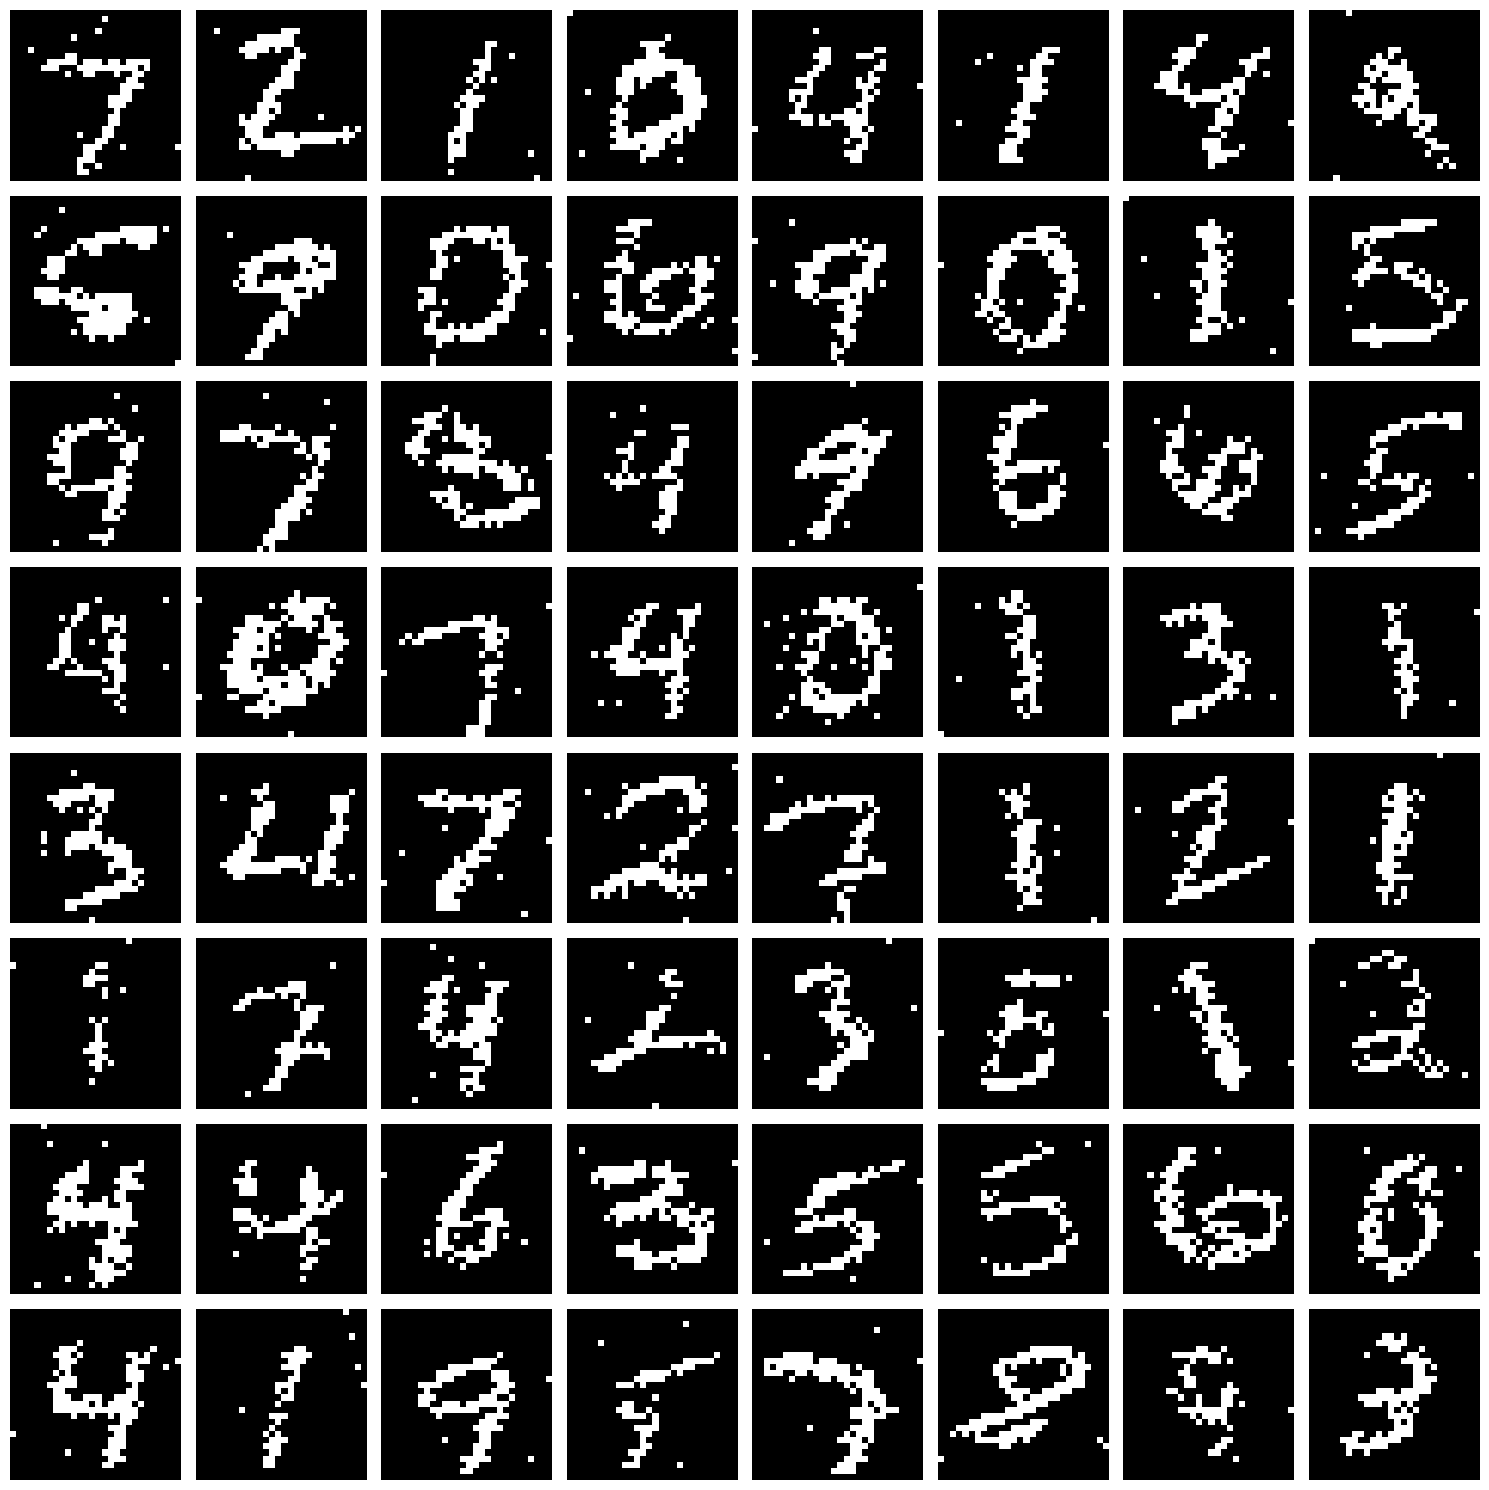

In [10]:
H, W = 28, 28

with torch.no_grad():
  for iter, (images, labels) in enumerate(test_loader):
      images = images.to(device)
      pred = model(images)

      for i in range(H):
          for j in range(W):
              pred[:, :, i, j] = torch.bernoulli(pred[:, :, i, j], out=pred[:, :, i, j])
      break

samples = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(8, 8, figsize=(15, 15))

for i in range(64):
    sample = samples[i]
    row, col = divmod(i, 8)
    axes[row, col].imshow(sample, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# f. Evaluation (Generation)

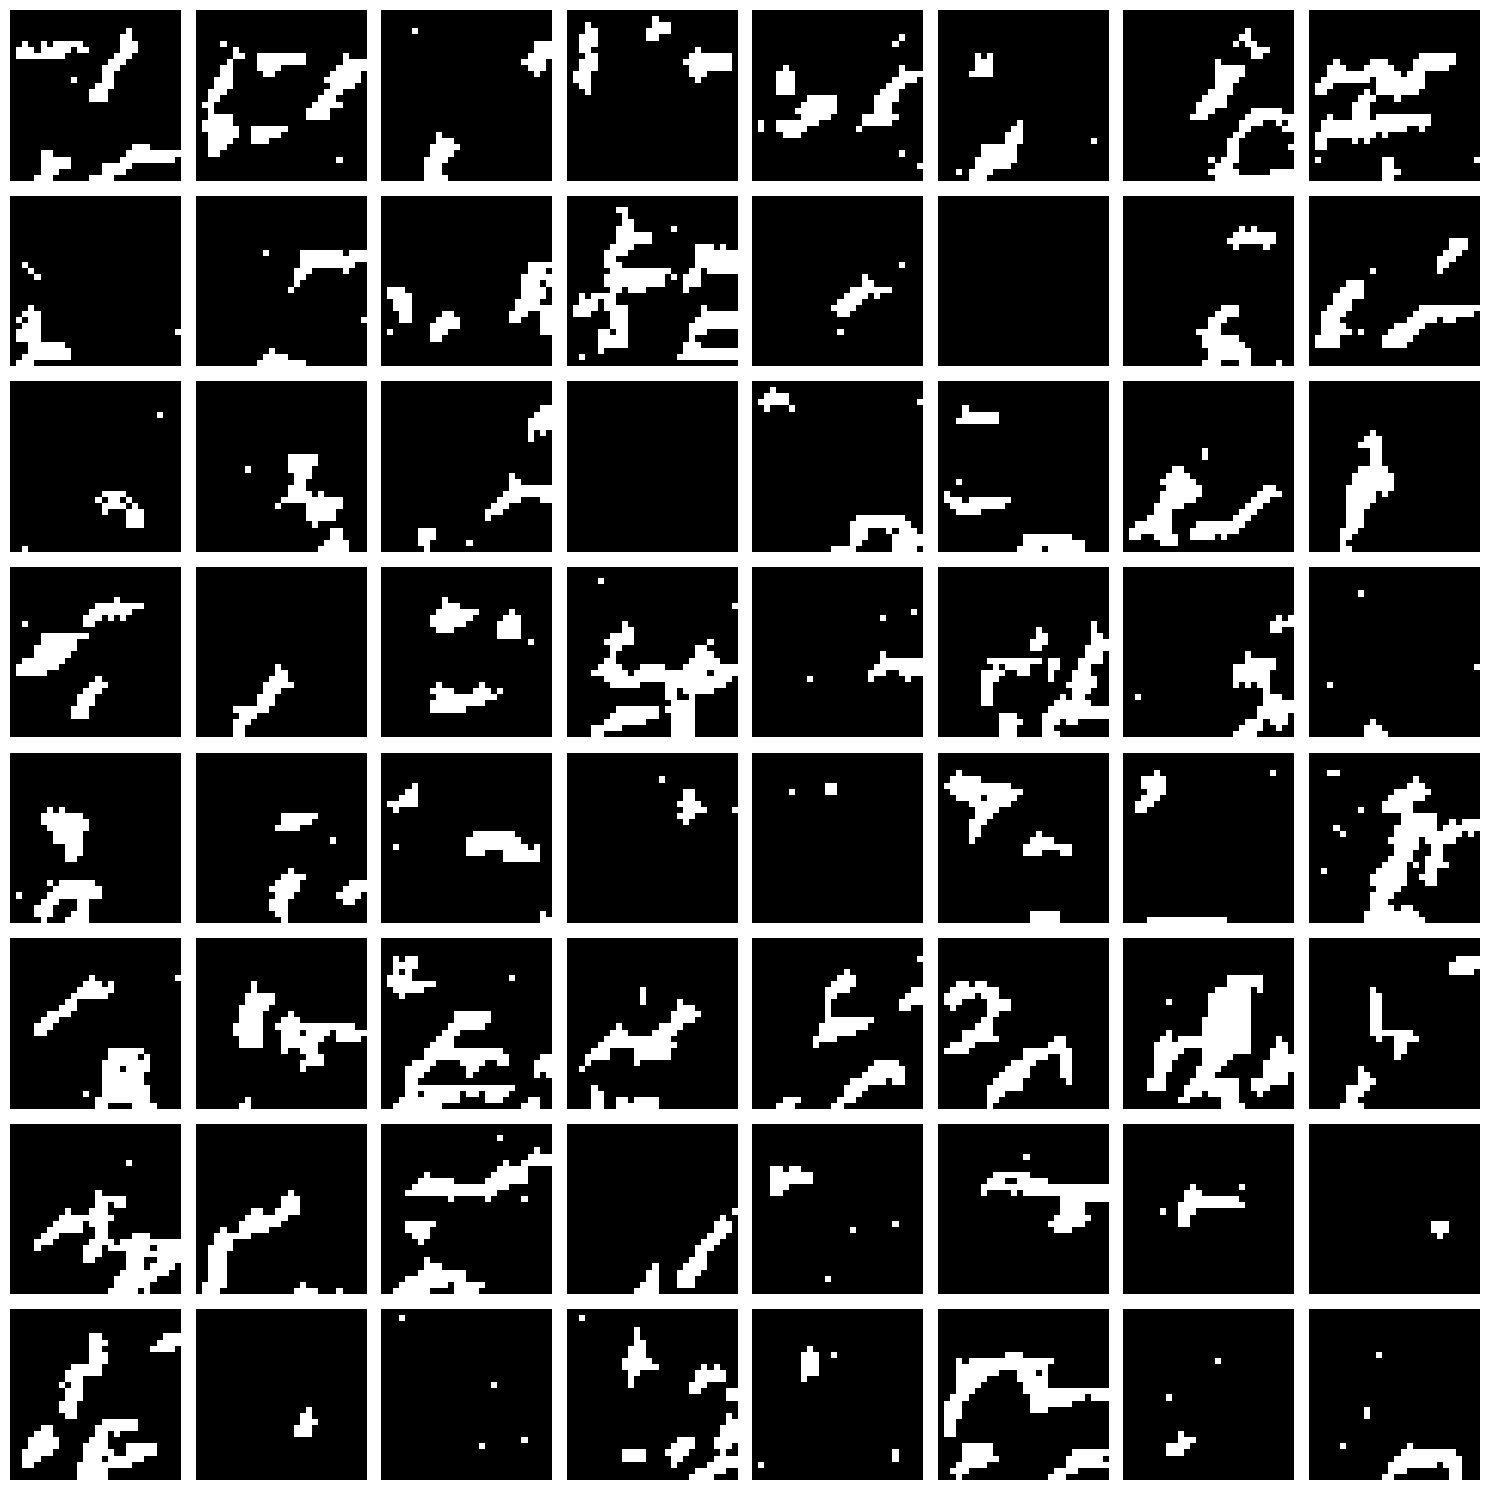

In [11]:
samples = torch.zeros(size=(64, 1, H, W)).to(device)
with torch.no_grad():
    for i in range(H):
        for j in range(W):
            if j > 0 and i > 0:
                out = model(samples)
                samples[:, :, i, j] = torch.bernoulli(out[:, :, i, j], out=samples[:, :, i, j])

samples = samples.cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(8, 8, figsize=(15, 15))

for i in range(64):
    sample = samples[i]
    row, col = divmod(i, 8)
    axes[row, col].imshow(sample, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# **2. Conditional PixelCNN**


# a. Training Function

In [63]:
def train_cond(dataloader, model, optimizer, epochs, n_classes):
    losses = []

    for epoch in tqdm(range(epochs), desc='Epochs'):
        running_loss = 0.0
        batch_progress = tqdm(dataloader, desc='Batches', leave=False)

        for iter, (images, labels) in enumerate(batch_progress):
            images = images.to(device)
            labels = labels.to(device)
            tgt = images.clone()
            pred = model(images, labels)
            loss = bce(pred, tgt)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            avg_loss = running_loss * batch_size / len(train_dataset)
            losses.append(loss.item())

        tqdm.write(f'----\nEpoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}\n')

    return losses

# b. Conditional Masked Convolution

In [62]:
class VerticalMaskedConv(nn.Conv2d):
    def __init__(self,*args,**kwargs):
        super().__init__(*args,**kwargs)
        h,w = self.kernel_size
        c = h // 2 # Rows > c should be masked
        mask = torch.ones_like(self.weight)
        mask[:,:,c+1:,:] = 0
        self.register_buffer('mask',mask)
    
    def forward(self, x):
        return F.conv2d(
            x,
            self.weight * self.mask,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups
        )

class HorizontalMaskedConv(nn.Conv2d):
    def __init__(self,*args,mask_type='A',**kwargs):
        super().__init__(*args,**kwargs)
        h,w = self.kernel_size
        c = h // 2 
        d = h // 2
        mask = torch.zeros_like(self.weight)
        mask[:,:,c,0:d] = 1
        if mask_type == 'B':
            mask[:,:,c,d] = 1
        self.register_buffer('mask',mask)

    def forward(self, x):
        return F.conv2d(
            x,
            self.weight * self.mask,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups
        )


In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. 核心辅助函数：下移
def shift_down(x):
    # 顶部补1行0，底部切掉1行
    return F.pad(x, (0, 0, 1, 0))[:, :, :-1, :]

# 2. 完整的 GatedBlock (修正了参数传递和标签注入)
class GatedBlock(nn.Module):
    def __init__(self, num_classes, mask_type, in_channels, p):
        super().__init__() # 必须有
        self.p = p
        self.mask_type = mask_type
        
        # --- 垂直卷积 ---
        # 显式写出参数，避免 *args 导致的 multiple values for kernel_size 报错
        self.verticalConv = VerticalMaskedConv(
            in_channels=in_channels, 
            out_channels=2*p, 
            kernel_size=(3,3), 
            padding=1
        )
        
        # --- 水平卷积 ---
        self.horizontalConv = HorizontalMaskedConv(
            mask_type=mask_type, 
            in_channels=in_channels, 
            out_channels=2*p, 
            kernel_size=(3,3), 
            padding=1
        )
        
        # --- 投影层 ---
        self.elementWiseConv1 = nn.Conv2d(in_channels=2*p, out_channels=2*p, kernel_size=(1,1))
        self.elementWiseConv2 = nn.Conv2d(in_channels=p, out_channels=p, kernel_size=(1,1))
        
        # --- 标签投影层 (V*y) ---
        self.v_label_projection = nn.Linear(num_classes, 2*p)
        self.h_label_projection = nn.Linear(num_classes, 2*p)

    def forward(self, v_input, h_input, y_one_hot):
        """
        注意：按你之前的习惯
        h_input 对应垂直流，v_input 对应水平流
        """
        # A. 准备标签偏置 [B, 2p, 1, 1]
        # 修正：y_one_hot 需要在 model.forward 里生成，这里直接用
        h_bias = self.h_label_projection(y_one_hot).unsqueeze(-1).unsqueeze(-1)
        v_bias = self.v_label_projection(y_one_hot).unsqueeze(-1).unsqueeze(-1)

        # B. 垂直分支计算 (h_output)
        resVerticalConv = self.verticalConv(h_input)
        
        # 标签注入必须在激活前！
        resVertical_with_bias = resVerticalConv + h_bias
        
        h1, h2 = resVertical_with_bias.chunk(2, dim=1)
        h_output = torch.tanh(h1) * torch.sigmoid(h2)

        # C. 水平分支计算 (v_output)
        resHorizontalConv = self.horizontalConv(v_input)
        
        # 关键：垂直信息下移后，通过 1x1 卷积融合
        h_to_v = self.elementWiseConv1(shift_down(resVerticalConv))
        
        # 融合垂直信息 + 水平信息 + 标签偏置
        totalConv = h_to_v + resHorizontalConv + v_bias

        v1, v2 = totalConv.chunk(2, dim=1)
        # 激活后再过 1x1 卷积
        v_delta = self.elementWiseConv2(torch.tanh(v1) * torch.sigmoid(v2))
        
        # D. 残差连接 (仅限 B 类 Block 且针对水平流 v_input)
        if self.mask_type == 'B':
            v_output = v_delta + v_input
        else:
            v_output = v_delta
            
        return v_output, h_output

# c. Model

In [76]:
class ConditionalPixelCNN(nn.Module):
    def __init__(self, num_classes, in_channels=1, hidden_channels=64, num_layers=5):
        super().__init__()
        self.num_classes = num_classes
        
        # 初始层
        self.v_conv_start = VerticalMaskedConv(in_channels=in_channels, out_channels=2*hidden_channels, kernel_size=3, padding=1)
        self.h_conv_start = HorizontalMaskedConv(mask_type='A', in_channels=in_channels, out_channels=2*hidden_channels, kernel_size=3, padding=1)
        
        self.blocks = nn.ModuleList([
            GatedBlock(num_classes, 'B', hidden_channels, hidden_channels)
            for _ in range(num_layers)
        ])
        
        self.out_layers = nn.Sequential(
            nn.Conv2d(hidden_channels, 128, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(128, in_channels, kernel_size=1),
            nn.Sigmoid() 
        )

    def forward(self, x, class_condition):
        y_one_hot = F.one_hot(class_condition, self.num_classes).float().to(x.device)
        
        # 1. 初始流：v 是垂直栈，h 是水平栈
        v_feat = self.v_conv_start(x)
        h_feat = self.h_conv_start(x)
        
        v1, v2 = v_feat.chunk(2, dim=1)
        v = torch.tanh(v1) * torch.sigmoid(v2)
        
        h1, h2 = h_feat.chunk(2, dim=1)
        h = torch.tanh(h1) * torch.sigmoid(h2)
        
        # 2. 循环处理 Blocks
        for block in self.blocks:
            # 修改 GatedBlock 使其符合 (v, h) -> (v, h) 的逻辑
            v, h = block(v, h, y_one_hot)
            
        # 3. ！！！核心修正：最终输出必须只来自水平栈 h ！！！
        # 因为 h 经过了 Mask A/B 和 shift_down，确保了因果性（不看当前像素）
        out = self.out_layers(h) 
        return out

# 对应的 GatedBlock 内部逻辑修正（对齐变量名）
class GatedBlock(nn.Module):
    def __init__(self, num_classes, mask_type, in_channels, p):
        super().__init__()
        self.mask_type = mask_type
        self.verticalConv = VerticalMaskedConv(in_channels=in_channels, out_channels=2*p, kernel_size=3, padding=1)
        self.horizontalConv = HorizontalMaskedConv(mask_type=mask_type, in_channels=in_channels, out_channels=2*p, kernel_size=3, padding=1)
        
        self.v_to_h = nn.Conv2d(2*p, 2*p, kernel_size=1)
        self.h_proj = nn.Conv2d(p, p, kernel_size=1)
        self.v_label_projection = nn.Linear(num_classes, 2*p)
        self.h_label_projection = nn.Linear(num_classes, 2*p)

    def forward(self, v_input, h_input, y_one_hot):
        v_bias = self.v_label_projection(y_one_hot).unsqueeze(-1).unsqueeze(-1)
        h_bias = self.h_label_projection(y_one_hot).unsqueeze(-1).unsqueeze(-1)

        # Vertical Branch
        v_raw = self.verticalConv(v_input)
        v1, v2 = (v_raw + v_bias).chunk(2, dim=1)
        v_output = torch.tanh(v1) * torch.sigmoid(v2)

        # Horizontal Branch
        h_raw = self.horizontalConv(h_input)
        # 你的逻辑：垂直信息向下平移后合并到水平支路
        v_shifted = shift_down(v_raw) 
        h_combined = h_raw + self.v_to_h(v_shifted) + h_bias
        
        h1, h2 = h_combined.chunk(2, dim=1)
        h_activated = torch.tanh(h1) * torch.sigmoid(h2)
        h_output = self.h_proj(h_activated)

        if self.mask_type == 'B':
            h_output = h_output + h_input
            
        return v_output, h_output

# d. Training

In [83]:
##################
epochs = 10
### Problem 3(c): Training
n_classes = 10
model = ConditionalPixelCNN(n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

log = train_cond(train_loader, model, optimizer, epochs, n_classes)
##################

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [1/10], Average Loss: 0.1180



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [2/10], Average Loss: 0.0872



...

----
Epoch [8/10], Average Loss: 0.0782



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [9/10], Average Loss: 0.0779



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [10/10], Average Loss: 0.0776



# e. Evaluation (Reconstruction)

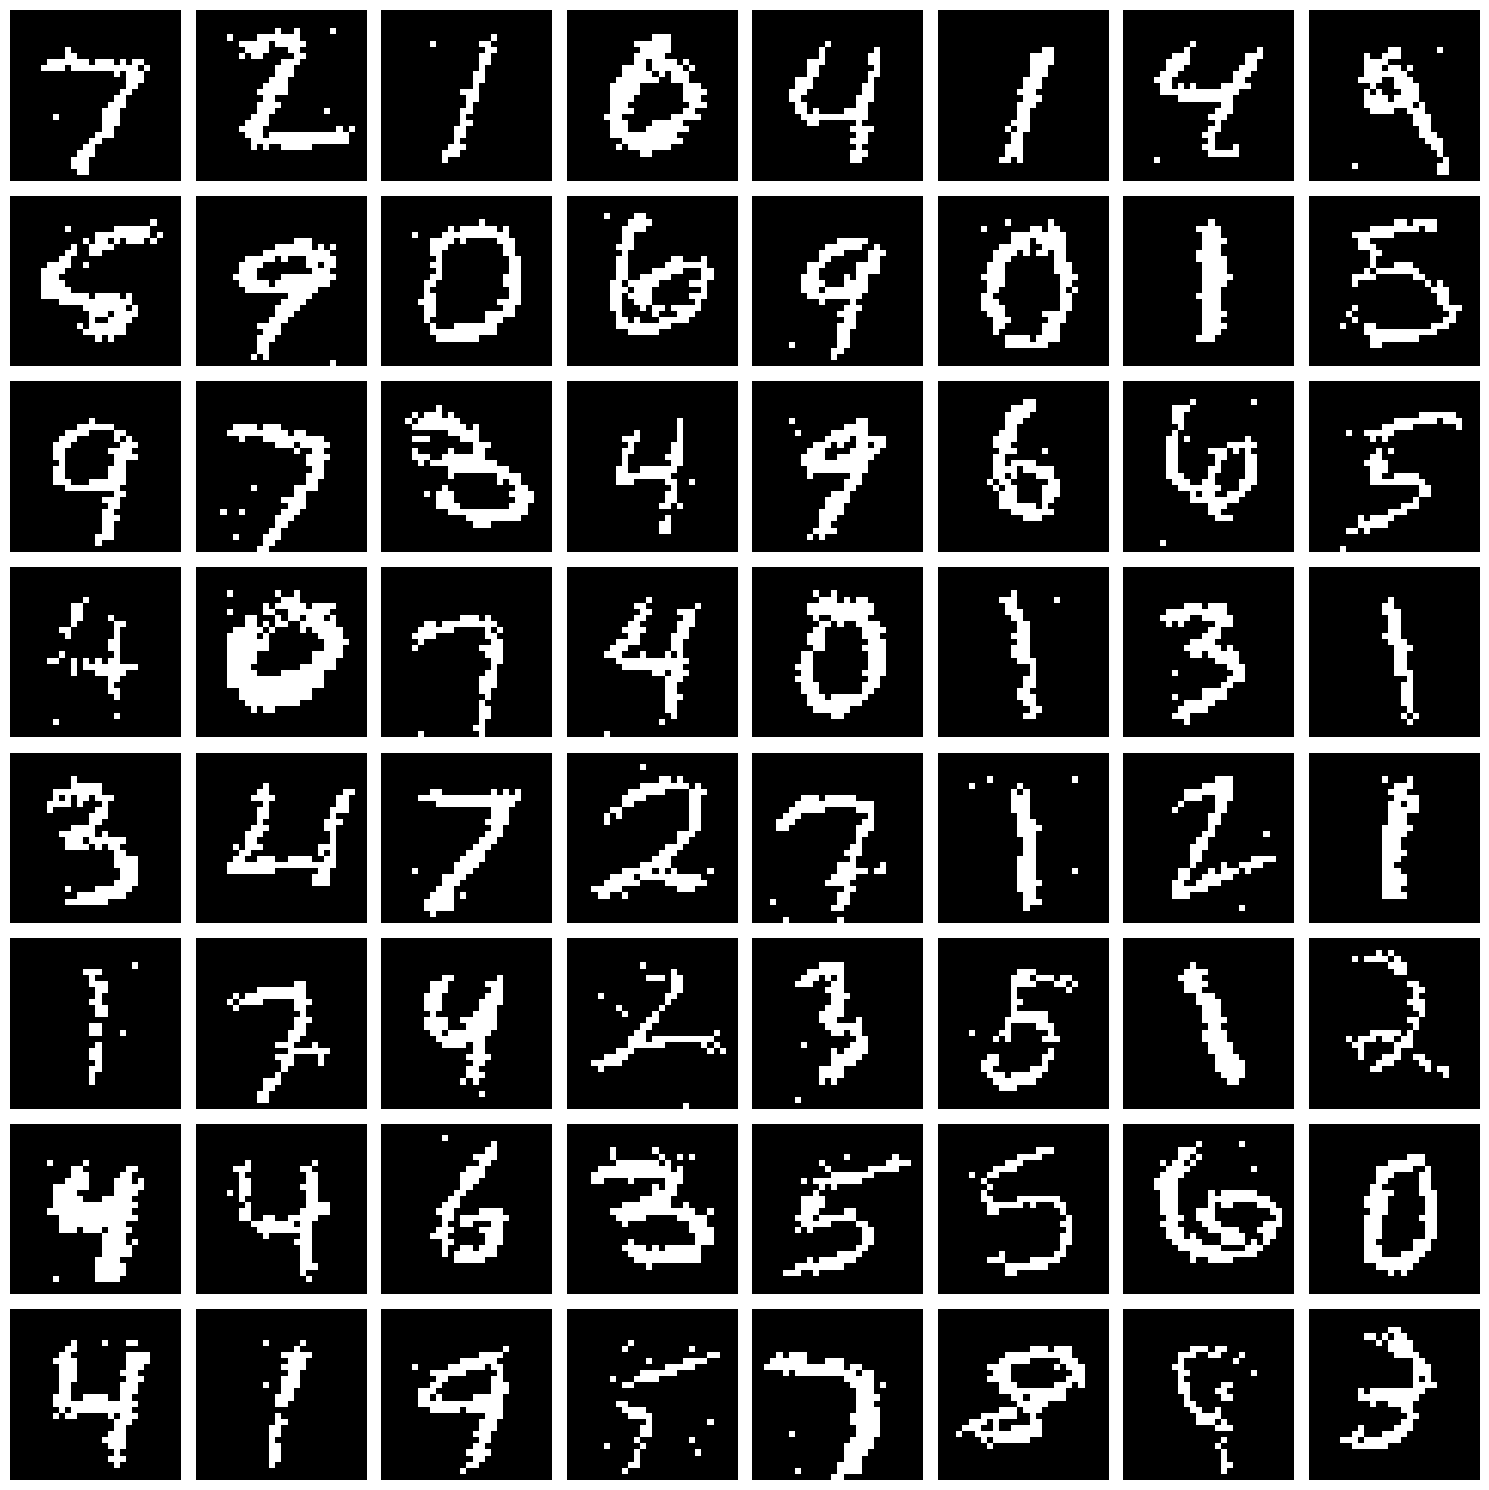

In [84]:
H, W = 28, 28

with torch.no_grad():
  for iter, (images, labels) in enumerate(test_loader):
      images = images.to(device)
      labels = labels.to(device)
      pred = model(images, labels)

      for i in range(H):
          for j in range(W):
              pred[:, :, i, j] = torch.bernoulli(pred[:, :, i, j], out=pred[:, :, i, j])
      break

samples = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(8, 8, figsize=(15, 15))

for i in range(64):
    sample = samples[i]
    row, col = divmod(i, 8)
    axes[row, col].imshow(sample, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# f. Evaluation (Generation)

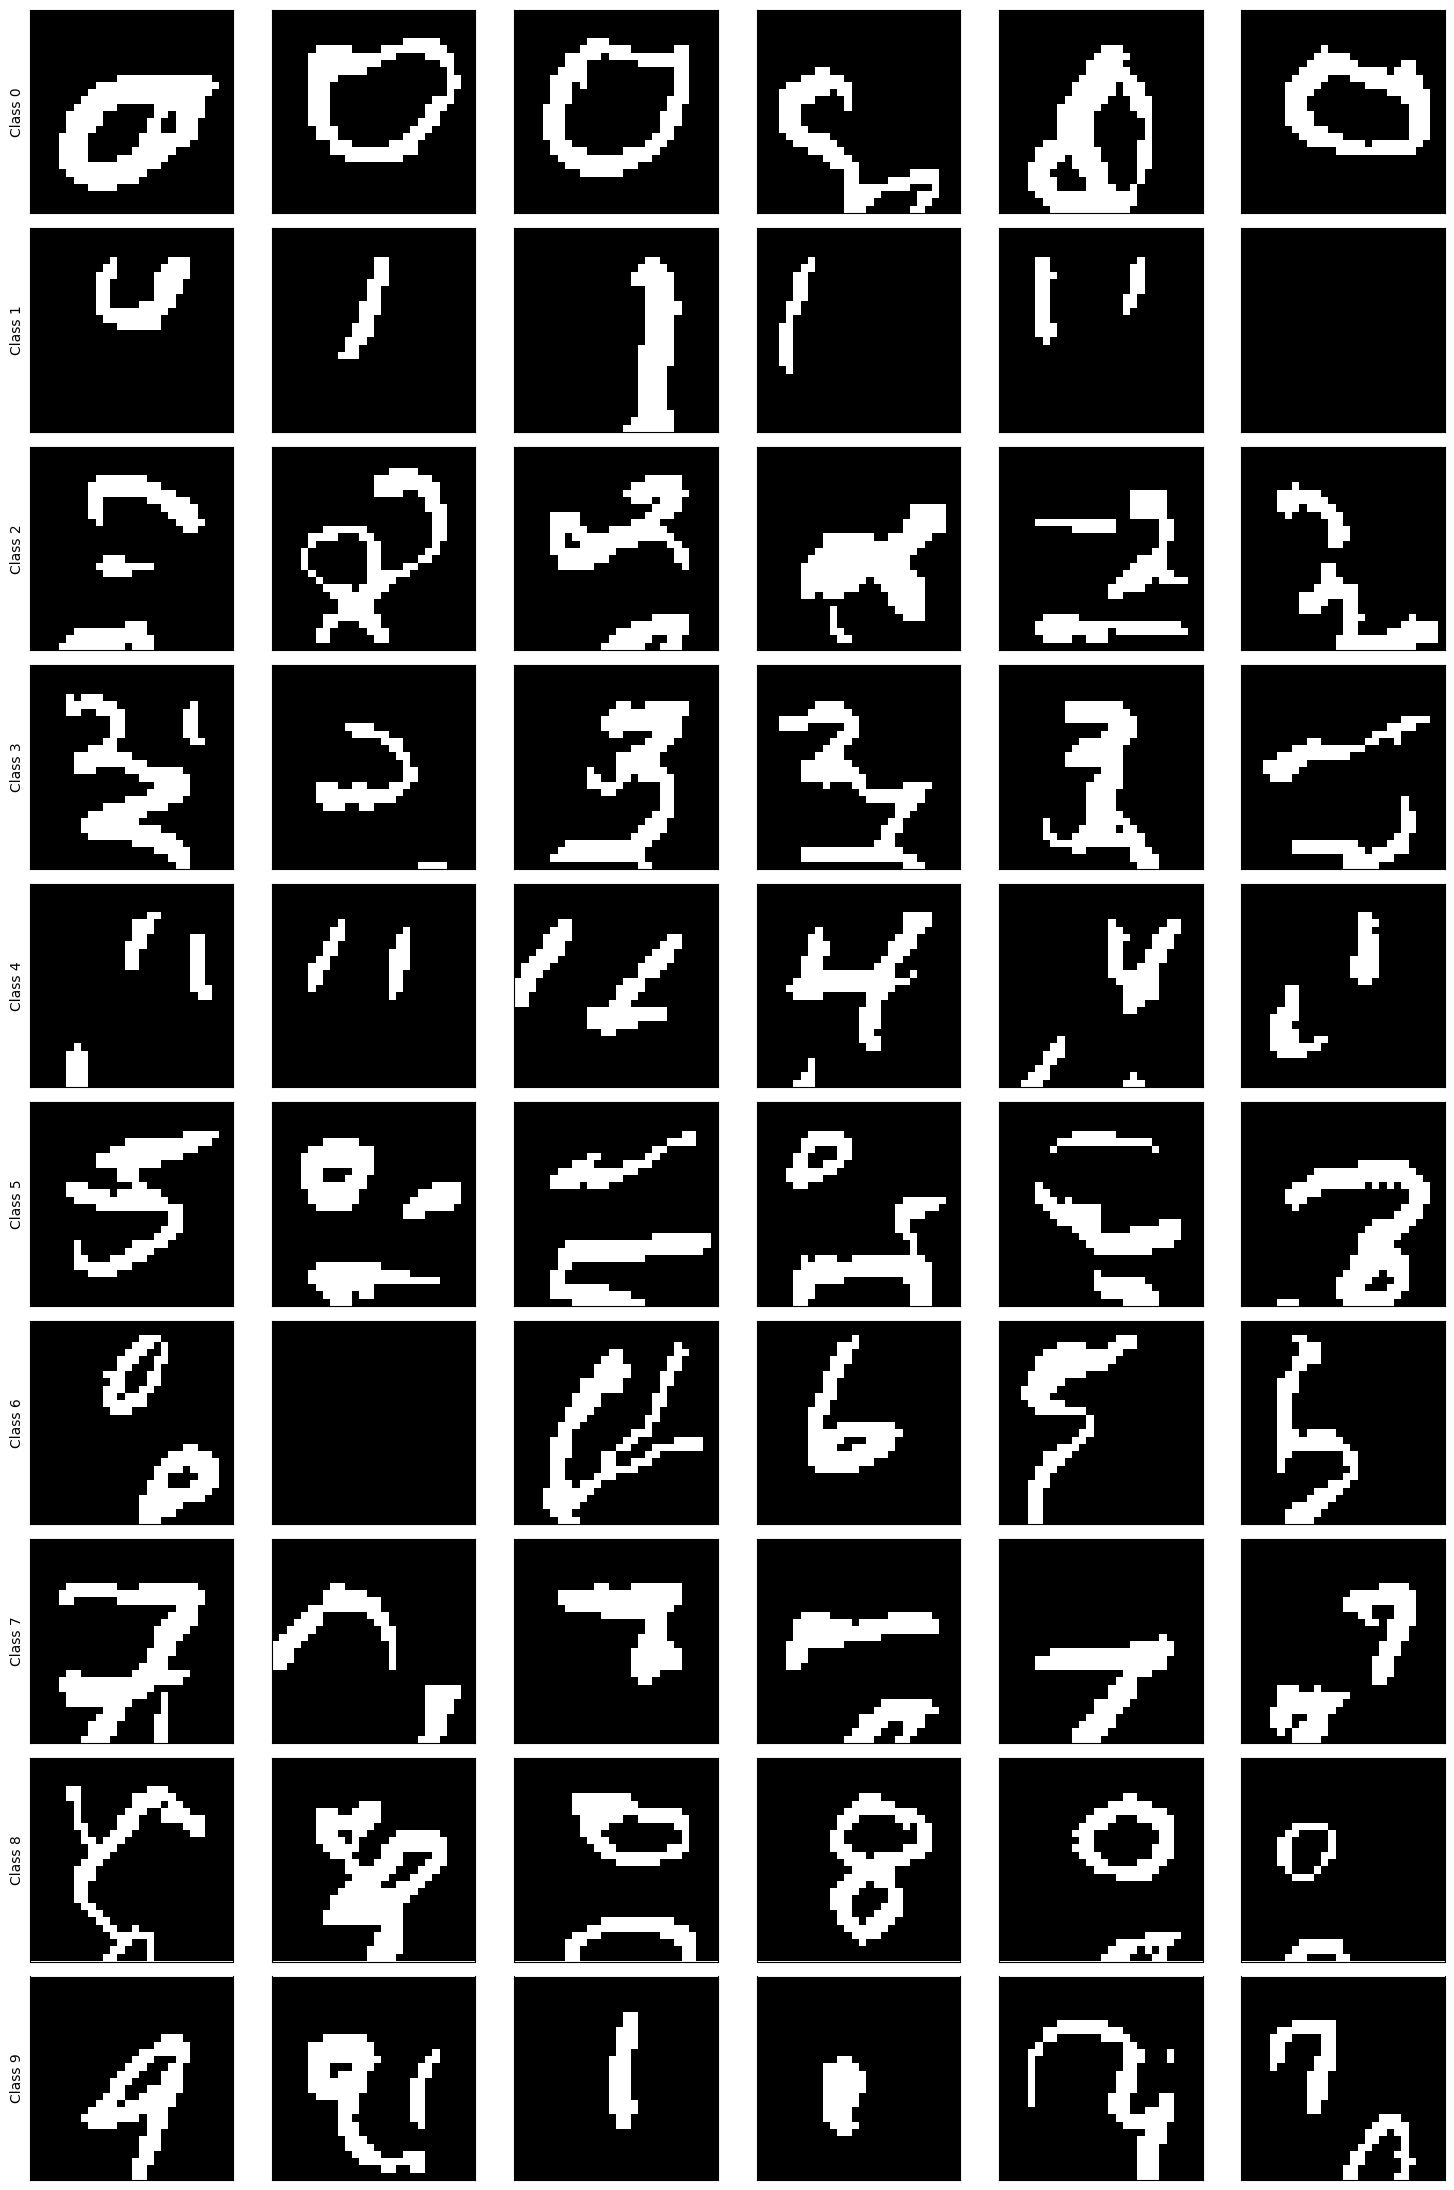

In [85]:
import torch
import numpy as np
import matplotlib.pyplot as plt

H, W = 28, 28
n_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 准备标签：保持为 LongTensor 索引，模型内部会处理 one-hot
sample_classes = np.sort(np.array([np.arange(n_classes)] * 6).flatten())
sample_classes = torch.tensor(sample_classes, dtype=torch.long).to(device)

# 2. 初始化画布：全黑 [60, 1, 28, 28]
samples = torch.zeros(size=(60, 1, H, W)).to(device)

model.eval()
with torch.no_grad():
    for i in range(H):
        for j in range(W):
            # 模型预测：现在的 out 维度应该是 [60, 1, 28, 28]
            out = model(samples, sample_classes)
            
            # --- 适配 1通道输出 ---
            # 直接取出第 0 个通道（也就是唯一的通道）在该位置的概率值
            # 维度从 [60, 1, 28, 28] 变为 [60]
            probs = out[:, 0, i, j] 
            
            # 伯努利采样并填回
            samples[:, 0, i, j] = torch.bernoulli(probs)

# 3. 绘图展示
samples_np = samples.cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(10, 6, figsize=(15, 22))

for i in range(60):
    sample = samples_np[i]
    row, col = divmod(i, 6)
    axes[row, col].imshow(sample.squeeze(), cmap='gray')
    
    if col == 0:
        axes[row, col].set_ylabel(f"Class {sample_classes[i].item()}", fontsize=10)
    axes[row, col].set_xticks([])
    axes[row, col].set_yticks([])

plt.tight_layout()
plt.show()

# Problem4


## (a)
$$
\begin{aligned}
\hat{\theta_{MAP}}&=\argmax_{\theta} \log p(\theta|x)\\
&= \argmax_{\theta} \log p(x|\theta) p(\theta)\\
&= \argmax_{\theta} \log p(x|\theta) + \log p(\theta)
\end{aligned}
$$

## (b)
$$
\begin{aligned}
\log p(\theta)= -\log (\sqrt{(2\pi)}\sigma) - \frac{(\theta-\mu)^2}{2\sigma^2}
\end{aligned}
$$